# Laboratorio 2 — Modelos de Aprendizaje No Supervisado


## Parte 1: Preparación del Entorno

In [1]:
# Parte 1: Preparación del entorno
# Descomenta la siguiente línea si ejecutas por primera vez en un entorno nuevo
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import warnings
warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

print("✓ Librerías importadas correctamente")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | sklearn importado")

✓ Librerías importadas correctamente
  pandas 2.2.2 | numpy 2.0.2 | sklearn importado


## Parte 2: Carga y Análisis Exploratorio de Datos (EDA)

### 2.1 Carga del dataset

El dataset **Mall Customers** contiene información de 200 clientes de un centro comercial.
Las variables disponibles son: `CustomerID`, `Genre`, `Age`, `Annual Income (k$)` y `Spending Score (1-100)`.
El objetivo es segmentar clientes según sus patrones de comportamiento y consumo.

In [2]:
# Parte 2.1: Carga del dataset
df = pd.read_csv('Mall_Customers.csv')

print("=" * 50)
print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print("=" * 50)
print("\nPrimeras filas:")
display(df.head(10))
print("\nTipos de datos y valores nulos:")
df.info()

Dimensiones del dataset: 200 filas × 5 columnas

Primeras filas:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 2.2 Análisis estadístico descriptivo

In [3]:
# Parte 2.2: Estadística descriptiva
print("Estadísticas descriptivas de variables numéricas:")
display(df.describe().round(2))

print(f"\nDistribución de género:")
genero = df['Genre'].value_counts()
for g, n in genero.items():
    print(f"  {g}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nValores nulos por columna:")
nulos = df.isnull().sum()
print(nulos.to_string())
print(f"\n→ Sin valores nulos. Dataset listo para preprocesamiento.")

Estadísticas descriptivas de variables numéricas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00



Distribución de género:
  Female: 112 (56.0%)
  Male: 88 (44.0%)

Valores nulos por columna:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0

→ Sin valores nulos. Dataset listo para preprocesamiento.


### 2.3 Visualización de distribuciones y correlaciones

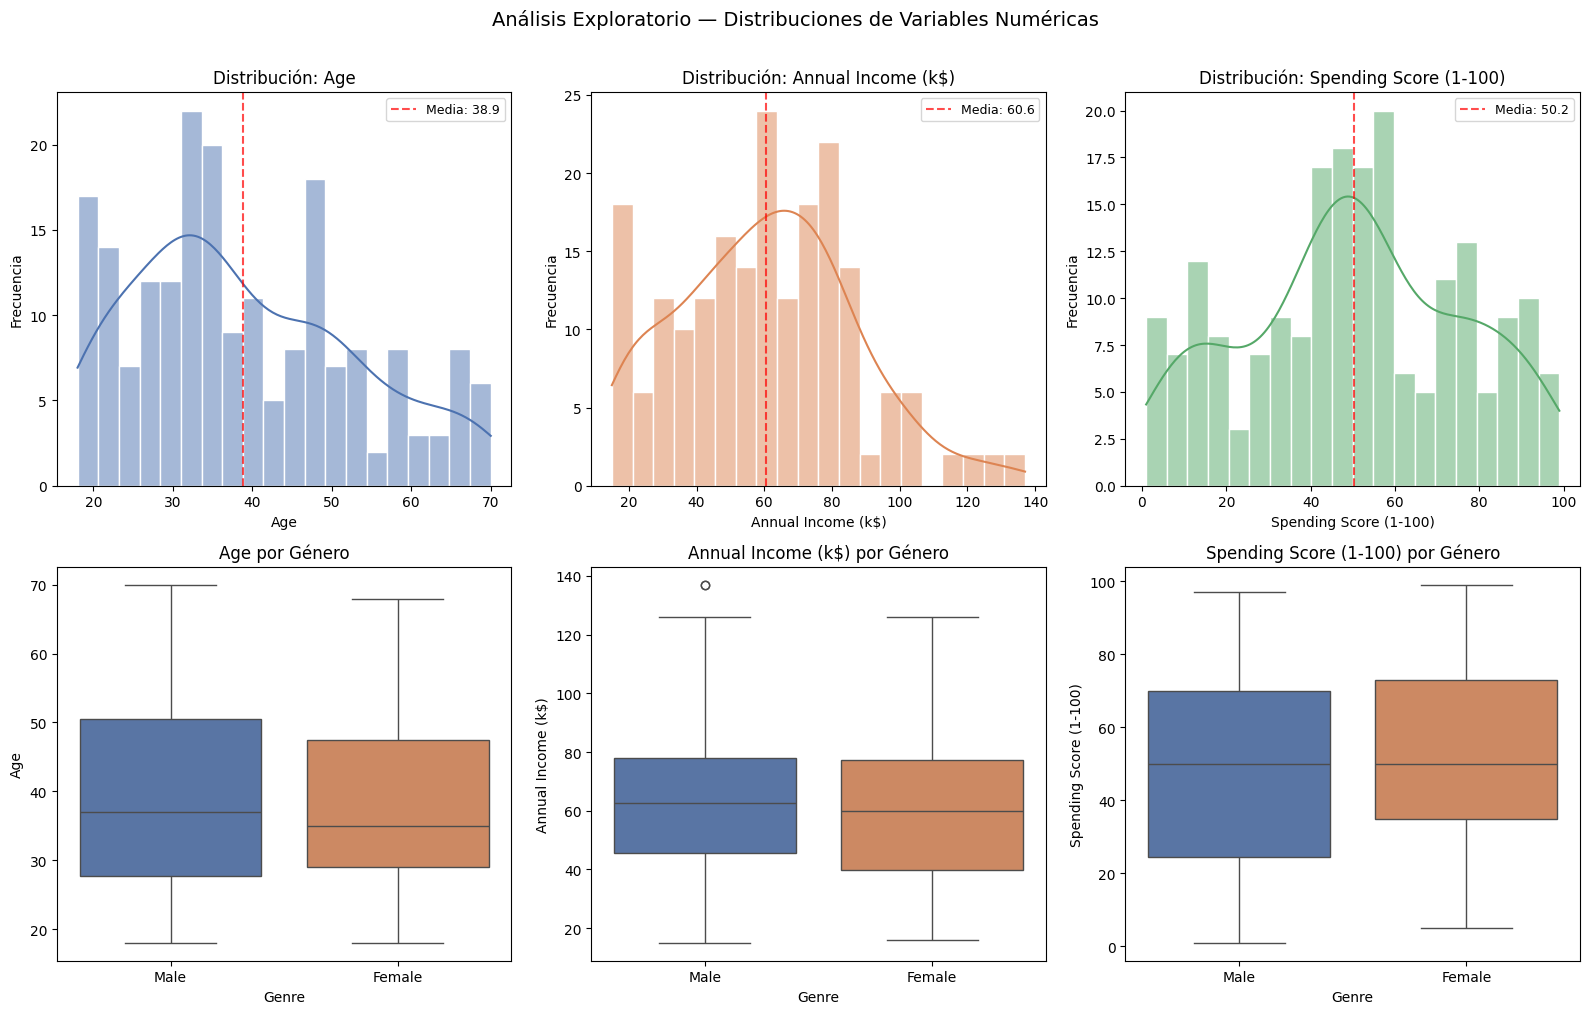

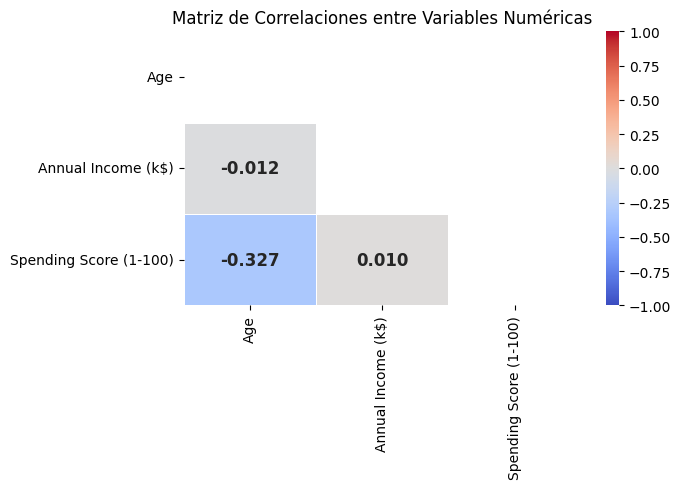

→ Las correlaciones son débiles entre todas las variables: cada una aporta información independiente.
→ Esto justifica usar las tres variables como features del modelo.


In [4]:
# Parte 2.3: Visualizaciones EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis Exploratorio — Distribuciones de Variables Numéricas', fontsize=14, y=1.01)

vars_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colores = ['#4C72B0', '#DD8452', '#55A868']

# Histogramas con KDE
for i, (var, color) in enumerate(zip(vars_num, colores)):
    sns.histplot(df[var], kde=True, ax=axes[0, i], color=color, bins=20, edgecolor='white')
    axes[0, i].set_title(f'Distribución: {var}')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].axvline(df[var].mean(), color='red', linestyle='--', alpha=0.7, label=f'Media: {df[var].mean():.1f}')
    axes[0, i].legend(fontsize=9)

# Boxplots por género
for i, (var, color) in enumerate(zip(vars_num, colores)):
    sns.boxplot(x='Genre', y=var, data=df, ax=axes[1, i], palette=['#4C72B0', '#DD8452'])
    axes[1, i].set_title(f'{var} por Género')

plt.tight_layout()
plt.show()

# Heatmap de correlaciones
plt.figure(figsize=(7, 5))
corr = df[vars_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlaciones entre Variables Numéricas', fontsize=12)
plt.tight_layout()
plt.show()

print("→ Las correlaciones son débiles entre todas las variables: cada una aporta información independiente.")
print("→ Esto justifica usar las tres variables como features del modelo.")

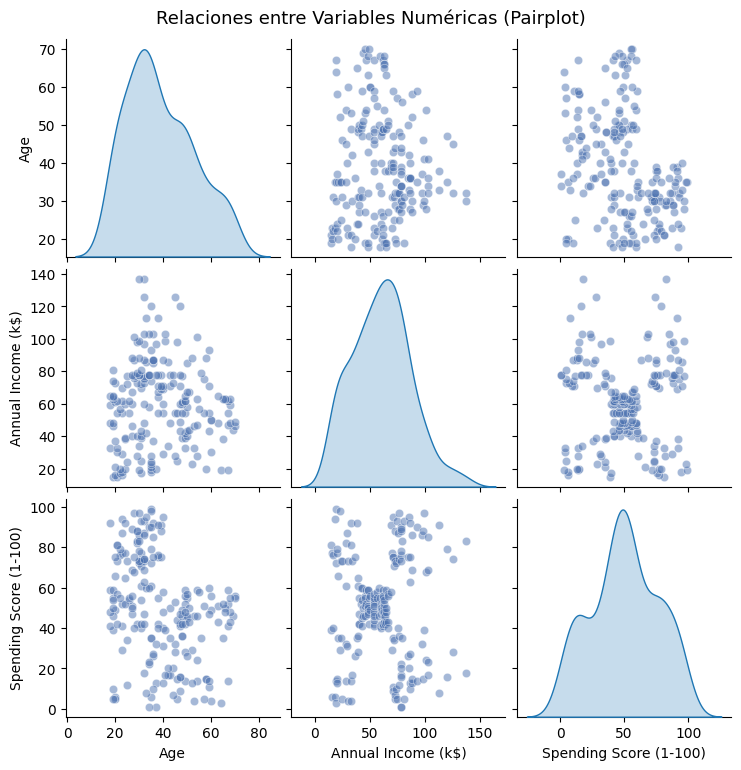

→ Se observan posibles agrupaciones en el plano Ingreso vs Gasto (4-5 clusters visibles).


In [5]:
# Parte 2.4: Pairplot — relaciones cruzadas entre variables
g = sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
                 diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#4C72B0'})
g.fig.suptitle('Relaciones entre Variables Numéricas (Pairplot)', y=1.02, fontsize=13)
plt.show()
print("→ Se observan posibles agrupaciones en el plano Ingreso vs Gasto (4-5 clusters visibles).")

## Parte 3: Limpieza y Preprocesamiento

### 3.1 Justificación de la selección de variables

Para los modelos de clustering se utilizan únicamente **tres variables numéricas**:
`Age`, `Annual Income (k$)` y `Spending Score (1-100)`.

**`CustomerID` se elimina** porque es un identificador arbitrario sin significado estadístico.
Incluirlo distorsionaría los cálculos de distancia euclidiana.

**`Genre` se excluye** porque es una variable categórica nominal. Para incluirla se requeriría
One-Hot Encoding, lo que añadiría dimensiones que podrían dominar el espacio de features en un
dataset tan pequeño (200 registros). En análisis de negocio real sería una variable a considerar.

> **Regla de oro del clustering basado en distancias:** solo se incluyen variables que
> aportan información de comportamiento o perfil, no identificadores ni variables que requieran
> transformaciones que alteren la escala de forma artificial.

In [6]:
# Parte 3.1: Limpieza — eliminar columnas irrelevantes
df_clean = df.drop(columns=['CustomerID', 'Genre'])

print("Columnas originales:", df.columns.tolist())
print("Columnas después de limpieza:", df_clean.columns.tolist())
print(f"\nShape resultante: {df_clean.shape}")
display(df_clean.head())

Columnas originales: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Columnas después de limpieza: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Shape resultante: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### 3.2 Escalado de variables con StandardScaler

K-Means y DBSCAN calculan **distancias euclidianas**. Si no se escalan las variables,
aquella con mayor rango numérico domina el resultado:

| Variable | Rango aprox. | Sin escalar: peso en distancia |
|---|---|---|
| Age | 18 – 70 | Medio |
| Annual Income (k$) | 15 – 137 | **Alto** (domina) |
| Spending Score | 1 – 99 | Medio |

`StandardScaler` transforma cada variable a media=0, desviación=1, eliminando este sesgo.

In [7]:
# Parte 3.2: Escalado con StandardScaler
X = df_clean[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar resultado
df_scaled_check = pd.DataFrame(X_scaled, columns=['Age_scaled', 'Income_scaled', 'Spending_scaled'])
print("Estadísticas tras escalar (debe ser media≈0, std≈1):")
display(df_scaled_check.describe().round(4))
print(f"\n✓ X_scaled shape: {X_scaled.shape} — listo para los modelos")

Estadísticas tras escalar (debe ser media≈0, std≈1):


,Age_scaled,Income_scaled,Spending_scaled
count,200.0000,200.0000,200.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0025,1.0025,1.0025
min,-1.4963,-1.7390,-1.9100
25%,-0.7248,-0.7275,-0.5998
50%,-0.2045,0.0359,-0.0078
75%,0.7284,0.6657,0.8851
max,2.2355,2.9177,1.8945



✓ X_scaled shape: (200, 3) — listo para los modelos


## Parte 4: Implementación de Modelos

### 4.1 K-Means Clustering

K-Means es un algoritmo iterativo que divide los datos en **K grupos** minimizando
la suma de distancias cuadradas de cada punto a su centroide (WCSS).

**Pasos del algoritmo:**
1. Inicializar K centroides aleatoriamente (usamos `k-means++` para mejor convergencia)
2. Asignar cada punto al centroide más cercano
3. Recalcular los centroides como la media de cada grupo
4. Repetir hasta convergencia

**Hiperparámetro clave:** K (número de clusters) — se determina con el método del Codo y Silhouette.

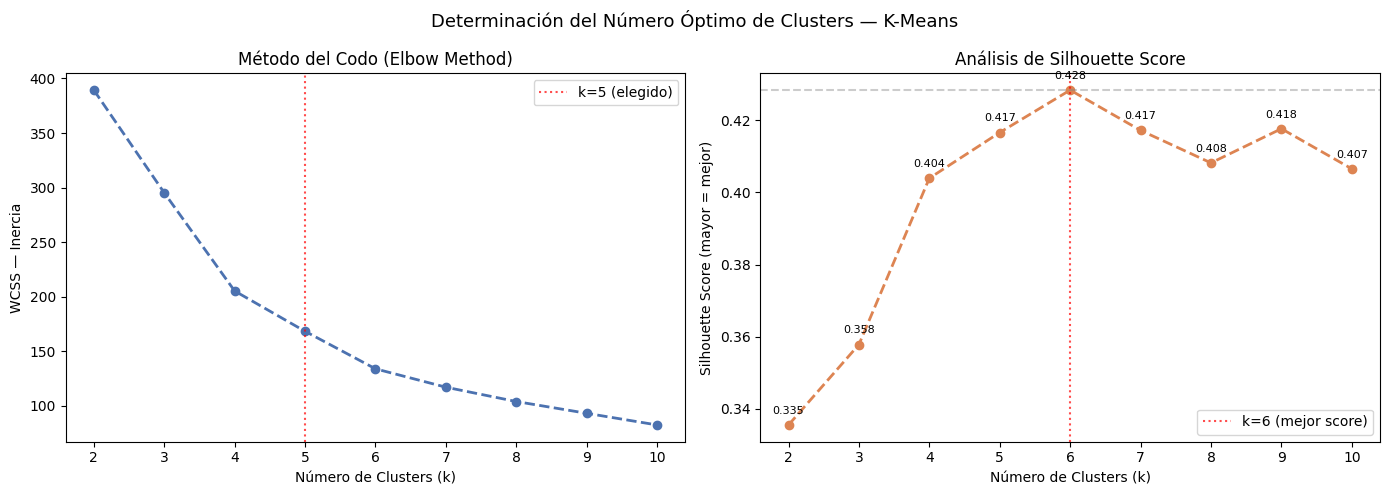

Scores de Silhouette por k:
  k=2: 0.3355
  k=3: 0.3578
  k=4: 0.4040
  k=5: 0.4166
  k=6: 0.4284 ← MEJOR
  k=7: 0.4172
  k=8: 0.4082
  k=9: 0.4177
  k=10: 0.4066

→ El método del codo muestra un quiebre claro en k=5.
→ Silhouette Score máximo = 0.4284 en k=6.
→ Se elige k=5 por ser el punto donde el codo es pronunciado y el Silhouette es alto,
  y porque produce perfiles de negocio claramente interpretables.


In [8]:
# Parte 4.1: Determinación del K óptimo — Elbow Method + Silhouette Score combinados
wcss = []
silhouette_avg = []
range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    kmeans_tmp = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=SEED)
    cluster_labels = kmeans_tmp.fit_predict(X_scaled)
    wcss.append(kmeans_tmp.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

# ─── Visualización combinada ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Determinación del Número Óptimo de Clusters — K-Means', fontsize=13)

# Gráfico 1: Elbow Method
axes[0].plot(range_n_clusters, wcss, marker='o', linestyle='--', color='#4C72B0', linewidth=2)
axes[0].set_title('Método del Codo (Elbow Method)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('WCSS — Inercia')
axes[0].set_xticks(range_n_clusters)
axes[0].axvline(x=5, color='red', linestyle=':', alpha=0.7, label='k=5 (elegido)')
axes[0].legend()

# Gráfico 2: Silhouette Score
best_k = list(range_n_clusters)[silhouette_avg.index(max(silhouette_avg))]
axes[1].plot(range_n_clusters, silhouette_avg, marker='o', linestyle='--', color='#DD8452', linewidth=2)
axes[1].set_title('Análisis de Silhouette Score')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score (mayor = mejor)')
axes[1].set_xticks(range_n_clusters)
axes[1].axvline(x=best_k, color='red', linestyle=':', alpha=0.7, label=f'k={best_k} (mejor score)')
axes[1].axhline(y=max(silhouette_avg), color='gray', linestyle='--', alpha=0.4)
axes[1].legend()

for k, (w, s) in zip(range_n_clusters, zip(wcss, silhouette_avg)):
    axes[1].annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print(f"Scores de Silhouette por k:")
for k, s in zip(range_n_clusters, silhouette_avg):
    marca = " ← MEJOR" if k == best_k else ""
    print(f"  k={k}: {s:.4f}{marca}")

print(f"\n→ El método del codo muestra un quiebre claro en k=5.")
print(f"→ Silhouette Score máximo = {max(silhouette_avg):.4f} en k={best_k}.")
print(f"→ Se elige k=5 por ser el punto donde el codo es pronunciado y el Silhouette es alto,")
print(f"  y porque produce perfiles de negocio claramente interpretables.")

#### 4.1.1 Entrenamiento del modelo final con k=5

In [9]:
# Parte 4.1.1: Modelo K-Means final con k=5
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=SEED)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

score_final_km = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f"✓ K-Means entrenado con k=5")
print(f"  Silhouette Score: {score_final_km:.4f}")
print(f"  WCSS (Inercia): {kmeans.inertia_:.2f}")
print(f"\nDistribución de clientes por cluster:")
dist = df['KMeans_Cluster'].value_counts().sort_index()
for cluster, count in dist.items():
    print(f"  Cluster {cluster}: {count} clientes ({count/len(df)*100:.1f}%)")

✓ K-Means entrenado con k=5
  Silhouette Score: 0.4166
  WCSS (Inercia): 168.25

Distribución de clientes por cluster:
  Cluster 0: 20 clientes (10.0%)
  Cluster 1: 54 clientes (27.0%)
  Cluster 2: 40 clientes (20.0%)
  Cluster 3: 39 clientes (19.5%)
  Cluster 4: 47 clientes (23.5%)


### 4.2 DBSCAN — Clustering Basado en Densidad

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos
con base en su **densidad local**, sin requerir especificar el número de clusters.

**Parámetros clave:**
- `eps` (ε): radio de vecindad — la distancia máxima entre dos puntos para considerarlos vecinos
- `min_samples`: mínimo de puntos en el radio eps para que un punto sea considerado *core point*

**Tipos de puntos:**
- **Core point**: tiene al menos `min_samples` vecinos dentro de radio `eps`
- **Border point**: dentro del radio de un core point, pero con menos vecinos que `min_samples`
- **Noise point (-1)**: no pertenece a ningún cluster — son outliers

**Ventaja frente a K-Means:** detecta clusters de forma arbitraria e identifica outliers automáticamente.

#### 4.2.1 Selección del parámetro eps con K-Distance Graph

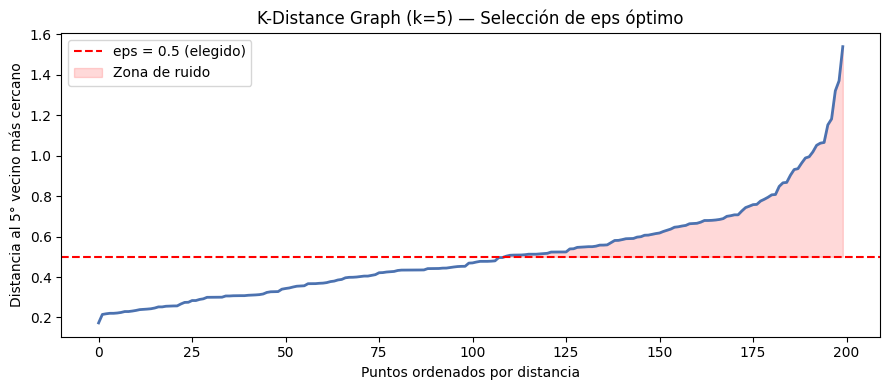

→ El codo de la curva se ubica alrededor de eps ≈ 0.5.
→ Por encima de ese valor los puntos empiezan a quedar aislados (ruido).
→ Se elige eps=0.5, min_samples=5.


In [10]:
# Parte 4.2.1: Selección de eps con K-Distance Graph
# Usamos min_samples=5 (regla práctica: dimensiones + 2 = 3 + 2 = 5)
MIN_SAMPLES = 5

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Distancia al k-ésimo vecino más cercano, ordenada ascendentemente
distances_sorted = np.sort(distances[:, MIN_SAMPLES - 1], axis=0)

plt.figure(figsize=(9, 4))
plt.plot(distances_sorted, color='#4C72B0', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='eps = 0.5 (elegido)')
plt.fill_between(range(len(distances_sorted)), distances_sorted, 0.5,
                 where=(distances_sorted > 0.5), alpha=0.15, color='red', label='Zona de ruido')
plt.title(f'K-Distance Graph (k={MIN_SAMPLES}) — Selección de eps óptimo', fontsize=12)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {MIN_SAMPLES}° vecino más cercano')
plt.legend()
plt.tight_layout()
plt.show()

print(f"→ El codo de la curva se ubica alrededor de eps ≈ 0.5.")
print(f"→ Por encima de ese valor los puntos empiezan a quedar aislados (ruido).")
print(f"→ Se elige eps=0.5, min_samples={MIN_SAMPLES}.")

#### 4.2.2 Entrenamiento y evaluación de DBSCAN

In [11]:
# Parte 4.2.2: Modelo DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()
mask_no_noise = db_labels != -1

print(f"✓ DBSCAN entrenado con eps=0.5, min_samples=5")
print(f"  Clusters encontrados: {n_clusters_db}")
print(f"  Puntos de ruido (-1): {n_noise_db} ({n_noise_db/len(df)*100:.1f}%)")

if n_clusters_db > 1:
    score_db = silhouette_score(X_scaled[mask_no_noise], db_labels[mask_no_noise])
    print(f"  Silhouette Score (sin ruido): {score_db:.4f}")

print(f"\nDistribución de puntos por cluster:")
counts = pd.Series(db_labels).value_counts().sort_index()
for label, count in counts.items():
    tipo = "Ruido/Outliers" if label == -1 else f"Cluster {label}"
    print(f"  {tipo}: {count} puntos ({count/len(df)*100:.1f}%)")

✓ DBSCAN entrenado con eps=0.5, min_samples=5
  Clusters encontrados: 6
  Puntos de ruido (-1): 60 (30.0%)
  Silhouette Score (sin ruido): 0.4817

Distribución de puntos por cluster:
  Ruido/Outliers: 60 puntos (30.0%)
  Cluster 0: 17 puntos (8.5%)
  Cluster 1: 5 puntos (2.5%)
  Cluster 2: 51 puntos (25.5%)
  Cluster 3: 28 puntos (14.0%)
  Cluster 4: 32 puntos (16.0%)
  Cluster 5: 7 puntos (3.5%)


### 4.3 Comparativa visual: K-Means vs DBSCAN

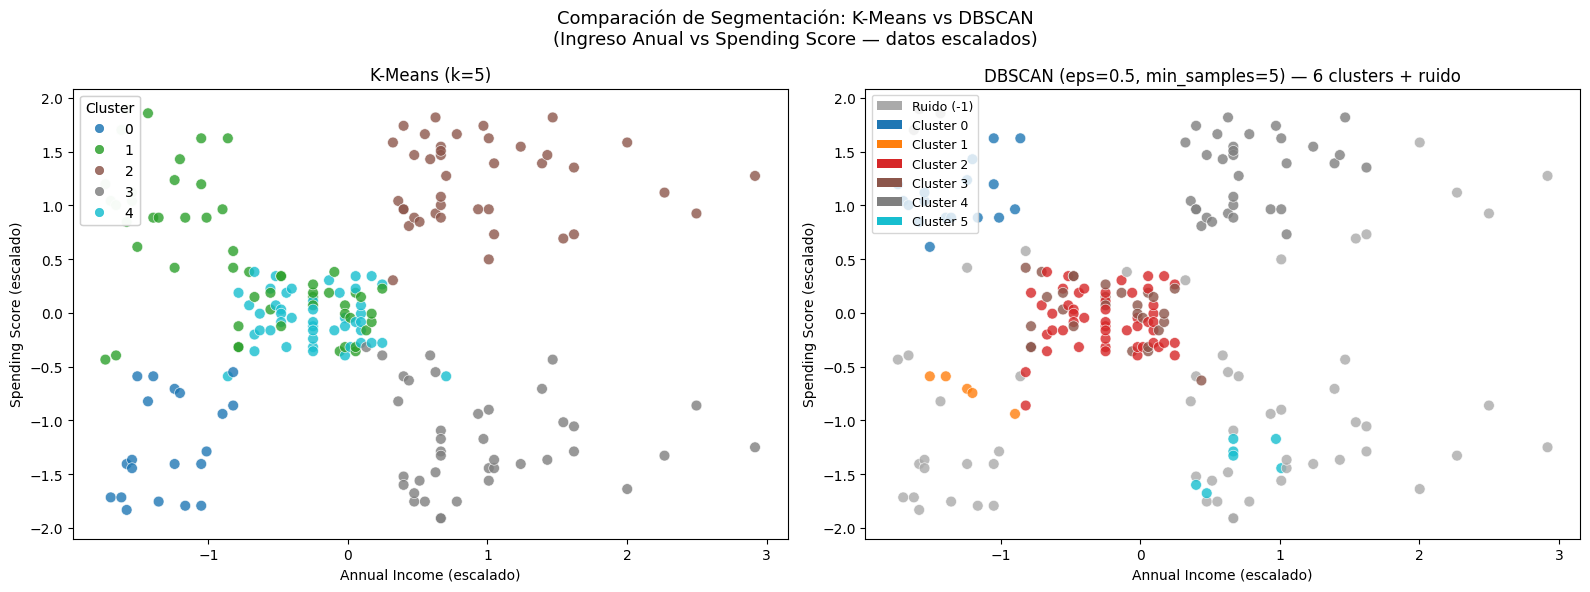

Diferencias clave observadas:
  K-Means: asigna TODOS los puntos a un cluster (no hay ruido).
  DBSCAN: detecta automáticamente outliers (puntos grises) y no asume forma esférica.
  K-Means genera 5 grupos uniformes; DBSCAN encuentra 6 zonas densas.


In [12]:
# Parte 4.3: Gráfico comparativo K-Means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de Segmentación: K-Means vs DBSCAN\n(Ingreso Anual vs Spending Score — datos escalados)',
             fontsize=13)

# K-Means
scatter_km = axes[0].scatter(X_scaled[:, 1], X_scaled[:, 2],
                              c=df['KMeans_Cluster'], cmap='tab10', alpha=0.8,
                              edgecolors='white', linewidths=0.5, s=60)
axes[0].set_title('K-Means (k=5)', fontsize=12)
axes[0].set_xlabel('Annual Income (escalado)')
axes[0].set_ylabel('Spending Score (escalado)')
legend_km = axes[0].legend(*scatter_km.legend_elements(), title='Cluster', loc='upper left')
axes[0].add_artist(legend_km)

# DBSCAN (−1 = ruido en gris)
palette_db = {-1: '#AAAAAA'}
unique_labels = sorted(set(db_labels))
cmap_vals = plt.cm.tab10(np.linspace(0, 0.9, n_clusters_db))
for i, lbl in enumerate([l for l in unique_labels if l != -1]):
    palette_db[lbl] = cmap_vals[i]

colors_db = [palette_db[l] for l in db_labels]
axes[1].scatter(X_scaled[:, 1], X_scaled[:, 2],
                c=colors_db, alpha=0.8, edgecolors='white', linewidths=0.5, s=60)
axes[1].set_title(f'DBSCAN (eps=0.5, min_samples=5) — {n_clusters_db} clusters + ruido', fontsize=12)
axes[1].set_xlabel('Annual Income (escalado)')
axes[1].set_ylabel('Spending Score (escalado)')

# Leyenda manual DBSCAN
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#AAAAAA', label='Ruido (-1)')]
for lbl in [l for l in unique_labels if l != -1]:
    legend_elements.append(Patch(facecolor=palette_db[lbl], label=f'Cluster {lbl}'))
axes[1].legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("Diferencias clave observadas:")
print("  K-Means: asigna TODOS los puntos a un cluster (no hay ruido).")
print("  DBSCAN: detecta automáticamente outliers (puntos grises) y no asume forma esférica.")
print(f"  K-Means genera {kmeans.n_clusters} grupos uniformes; DBSCAN encuentra {n_clusters_db} zonas densas.")

## Parte 5: Reducción Dimensional — PCA y t-SNE

### 5.1 PCA — Análisis de Componentes Principales (Reducción Lineal)

PCA transforma las variables originales en **componentes principales** — combinaciones
lineales ortogonales que maximizan la varianza explicada. Cada componente captura
la dirección de mayor dispersión en los datos.

**¿Por qué reducir a 2D?** Para poder visualizar clusters en un plano 2D, ya que los
datos originales tienen 3 dimensiones. Si se conserva suficiente varianza (>80%),
la visualización es representativa.

Varianza explicada por componente principal:
  PC1: 44.3%
  PC2: 33.3%
  Total conservada en 2D: 77.6%

Loadings (contribución de cada variable a cada componente):


,PC1,PC2
Age,0.7064,0.0301
Annual Income (k$),-0.0480,0.9988
Spending Score (1-100),-0.7062,-0.0378


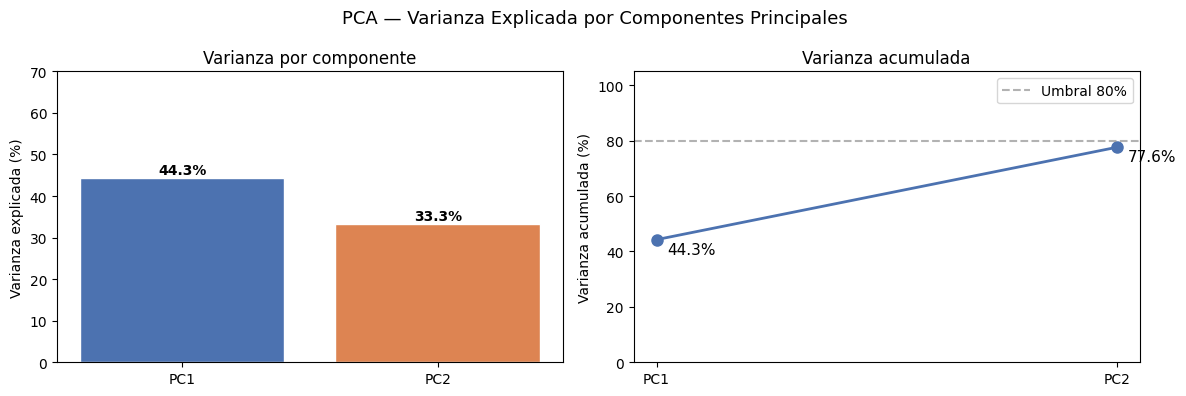

In [13]:
# Parte 5.1: PCA — Reducción a 2 componentes
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
var_pc1 = pca.explained_variance_ratio_[0]
var_pc2 = pca.explained_variance_ratio_[1]
var_total = pca.explained_variance_ratio_.sum()

print("Varianza explicada por componente principal:")
print(f"  PC1: {var_pc1*100:.1f}%")
print(f"  PC2: {var_pc2*100:.1f}%")
print(f"  Total conservada en 2D: {var_total*100:.1f}%")

# Loadings — contribución de cada variable
loadings = pd.DataFrame(
    pca.components_.T,
    index=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    columns=['PC1', 'PC2']
)
print(f"\nLoadings (contribución de cada variable a cada componente):")
display(loadings.round(4))

# Gráficas de varianza
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA — Varianza Explicada por Componentes Principales', fontsize=13)

axes[0].bar(['PC1', 'PC2'], [var_pc1*100, var_pc2*100], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente')
axes[0].set_ylim(0, 70)
for i, v in enumerate([var_pc1, var_pc2]):
    axes[0].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')

axes[1].plot(['PC1', 'PC2'], np.cumsum([var_pc1, var_pc2])*100,
             marker='o', color='#4C72B0', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='Umbral 80%')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].set_ylim(0, 105)
axes[1].legend()
for i, v in enumerate(np.cumsum([var_pc1, var_pc2])*100):
    axes[1].annotate(f'{v:.1f}%', (i, v), textcoords='offset points', xytext=(8, -10), fontsize=11)

plt.tight_layout()
plt.show()

### 5.2 t-SNE — Reducción No Lineal para Visualización

t-SNE (t-distributed Stochastic Neighbor Embedding) es una técnica **no lineal** diseñada
específicamente para **visualización**. A diferencia de PCA, t-SNE preserva la estructura
*local* de los datos: puntos cercanos en el espacio original permanecen cercanos en 2D.

**Parámetros importantes:**
- `perplexity`: balance entre estructura local y global (recomendado: 5–50)
- `learning_rate`: paso de optimización (200 es el valor estándar)

**Limitación clave:** t-SNE es **estocástico** y **no preserva distancias globales**.
No se debe interpretar la distancia absoluta entre clusters, solo si los puntos se agrupan.

In [14]:
# Parte 5.2: t-SNE — Reducción no lineal
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=SEED)
X_tsne = tsne.fit_transform(X_scaled)
print("✓ t-SNE completado")

✓ t-SNE completado


### 5.3 Visualización Comparativa: PCA vs t-SNE

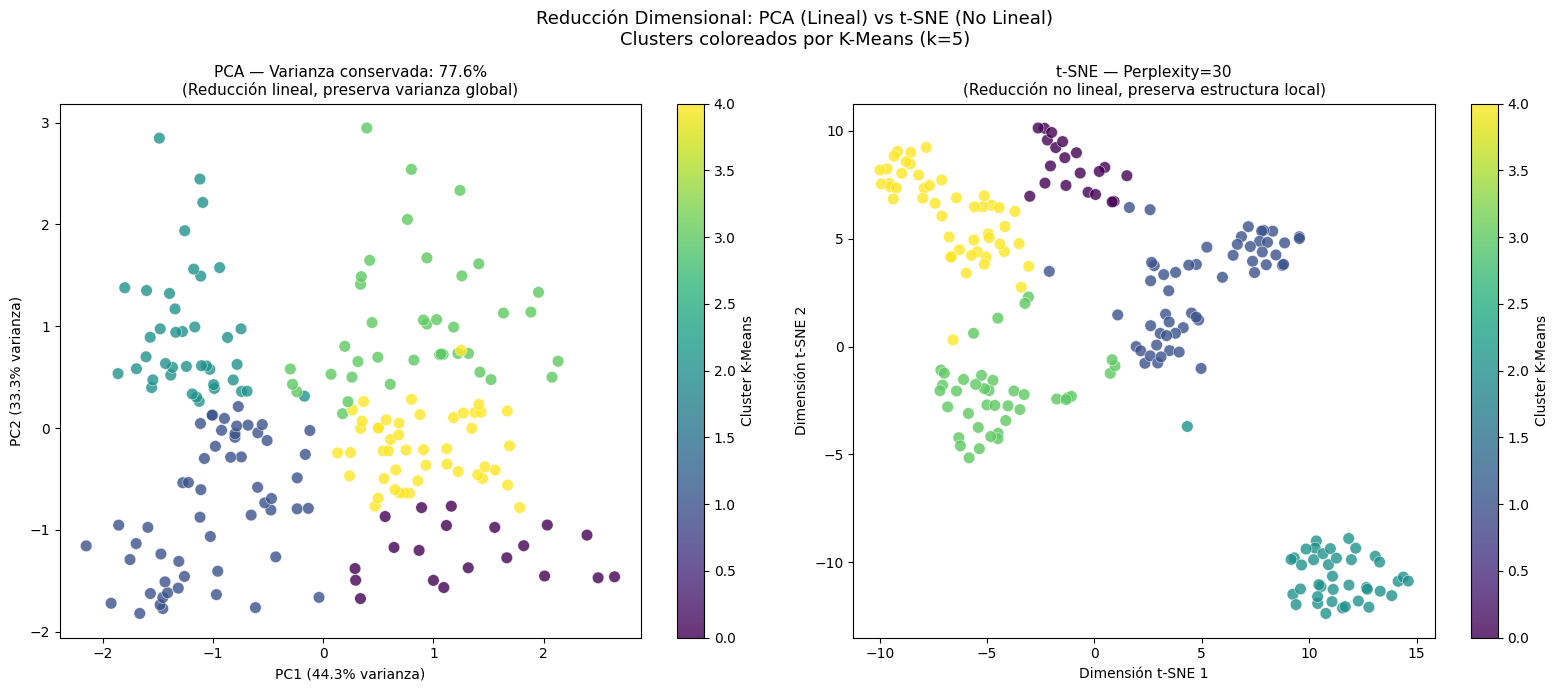

Diferencias entre PCA y t-SNE:
  PCA: preserva la varianza global; los ejes tienen interpretación (loadings).
  t-SNE: revela grupos compactos que PCA puede solapar; ejes sin interpretación propia.
  Ambas técnicas confirman la existencia de agrupaciones claras en los datos.


In [15]:
# Parte 5.3: Comparativa PCA vs t-SNE coloreados por cluster K-Means
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Reducción Dimensional: PCA (Lineal) vs t-SNE (No Lineal)\nClusters coloreados por K-Means (k=5)',
             fontsize=13)

# PCA
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['KMeans_Cluster'], cmap='viridis', alpha=0.8,
                       edgecolors='white', linewidths=0.4, s=70)
axes[0].set_title(f'PCA — Varianza conservada: {var_total*100:.1f}%\n(Reducción lineal, preserva varianza global)', fontsize=11)
axes[0].set_xlabel(f'PC1 ({var_pc1*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({var_pc2*100:.1f}% varianza)')
plt.colorbar(sc1, ax=axes[0], label='Cluster K-Means')

# t-SNE
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=df['KMeans_Cluster'], cmap='viridis', alpha=0.8,
                       edgecolors='white', linewidths=0.4, s=70)
axes[1].set_title('t-SNE — Perplexity=30\n(Reducción no lineal, preserva estructura local)', fontsize=11)
axes[1].set_xlabel('Dimensión t-SNE 1')
axes[1].set_ylabel('Dimensión t-SNE 2')
plt.colorbar(sc2, ax=axes[1], label='Cluster K-Means')

plt.tight_layout()
plt.show()

print("Diferencias entre PCA y t-SNE:")
print("  PCA: preserva la varianza global; los ejes tienen interpretación (loadings).")
print("  t-SNE: revela grupos compactos que PCA puede solapar; ejes sin interpretación propia.")
print("  Ambas técnicas confirman la existencia de agrupaciones claras en los datos.")

## Parte 6: Interpretación de Clusters — Perfilamiento de Segmentos

Una vez identificados los clusters, el paso más importante para el negocio es
**interpretar qué representa cada grupo**. Calculamos las medias de las variables
originales por cluster para asignar un perfil de cliente a cada segmento.

In [16]:
# Parte 6.1: Tabla resumen de características medias por cluster
resumen = (df.groupby('KMeans_Cluster')
             [['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
             .mean()
             .round(1))

# Añadir tamaño de cada cluster
resumen['Nro. Clientes'] = df['KMeans_Cluster'].value_counts().sort_index()
resumen['% del Total'] = (resumen['Nro. Clientes'] / len(df) * 100).round(1)

print("=" * 65)
print("TABLA RESUMEN: Características Medias por Cluster (K-Means k=5)")
print("=" * 65)
display(resumen)

TABLA RESUMEN: Características Medias por Cluster (K-Means k=5)


,Age,Annual Income (k$),Spending Score (1-100),Nro. Clientes,% del Total
KMeans_Cluster,,,,,
0,46.2,26.8,18.4,20,10.0
1,25.2,41.1,62.2,54,27.0
2,32.9,86.1,81.5,40,20.0
3,39.9,86.1,19.4,39,19.5
4,55.6,54.4,48.9,47,23.5


In [17]:
# Parte 6.2: Asignación de nombres de perfil a cada cluster
# Basado en las medias: Ingreso y Spending Score son los ejes principales
perfil_nombres = {
    0: "Ahorradores Maduros",
    1: "Jóvenes Moderados",
    2: "Premium Activos",
    3: "Alto Ingreso Conservador",
    4: "Seniors Estables"
}

# Identificar perfiles dinámicamente por ingreso y gasto
medias = df.groupby('KMeans_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()

perfil_dinamico = {}
for cluster_id, row in medias.iterrows():
    income = row['Annual Income (k$)']
    spend = row['Spending Score (1-100)']
    age = row['Age']
    if income >= 70 and spend >= 70:
        nombre = "💎 Premium Activos"
        desc = "Ingresos altos + gasto alto → Segmento ideal para productos premium y lealtad"
    elif income >= 70 and spend < 40:
        nombre = "💼 Alto Ingreso Conservador"
        desc = "Ingresos altos + gasto bajo → Potencial sin explotar; estrategia de activación"
    elif income < 45 and spend >= 55:
        nombre = "🛍️ Jóvenes Impulsivos"
        desc = "Ingresos bajos + gasto alto → Clientes aspiracionales; riesgo de sobreendeudamiento"
    elif income < 45 and spend < 40:
        nombre = "📉 Ahorradores de Bajo Ingreso"
        desc = "Ingresos bajos + gasto bajo → Segmento básico; estrategia de fidelización económica"
    else:
        nombre = "⚖️ Perfil Estándar / Moderado"
        desc = "Ingreso y gasto medios → Base estable; campañas de cross-selling"
    perfil_dinamico[cluster_id] = {'Nombre': nombre, 'Descripción': desc,
                                    'Ingreso Medio': f"${income:.0f}k",
                                    'Gasto Medio': f"{spend:.0f}/100",
                                    'Edad Media': f"{age:.0f} años"}

print("\n🎯 PERFILES DE CLIENTE IDENTIFICADOS")
print("=" * 65)
for cluster_id, info in perfil_dinamico.items():
    n = df[df['KMeans_Cluster']==cluster_id].shape[0]
    print(f"\nCluster {cluster_id} — {info['Nombre']} ({n} clientes)")
    print(f"  Ingreso: {info['Ingreso Medio']} | Gasto: {info['Gasto Medio']} | Edad: {info['Edad Media']}")
    print(f"  → {info['Descripción']}")


🎯 PERFILES DE CLIENTE IDENTIFICADOS

Cluster 0 — 📉 Ahorradores de Bajo Ingreso (20 clientes)
  Ingreso: $27k | Gasto: 18/100 | Edad: 46 años
  → Ingresos bajos + gasto bajo → Segmento básico; estrategia de fidelización económica

Cluster 1 — 🛍️ Jóvenes Impulsivos (54 clientes)
  Ingreso: $41k | Gasto: 62/100 | Edad: 25 años
  → Ingresos bajos + gasto alto → Clientes aspiracionales; riesgo de sobreendeudamiento

Cluster 2 — 💎 Premium Activos (40 clientes)
  Ingreso: $86k | Gasto: 82/100 | Edad: 33 años
  → Ingresos altos + gasto alto → Segmento ideal para productos premium y lealtad

Cluster 3 — 💼 Alto Ingreso Conservador (39 clientes)
  Ingreso: $86k | Gasto: 19/100 | Edad: 40 años
  → Ingresos altos + gasto bajo → Potencial sin explotar; estrategia de activación

Cluster 4 — ⚖️ Perfil Estándar / Moderado (47 clientes)
  Ingreso: $54k | Gasto: 49/100 | Edad: 56 años
  → Ingreso y gasto medios → Base estable; campañas de cross-selling


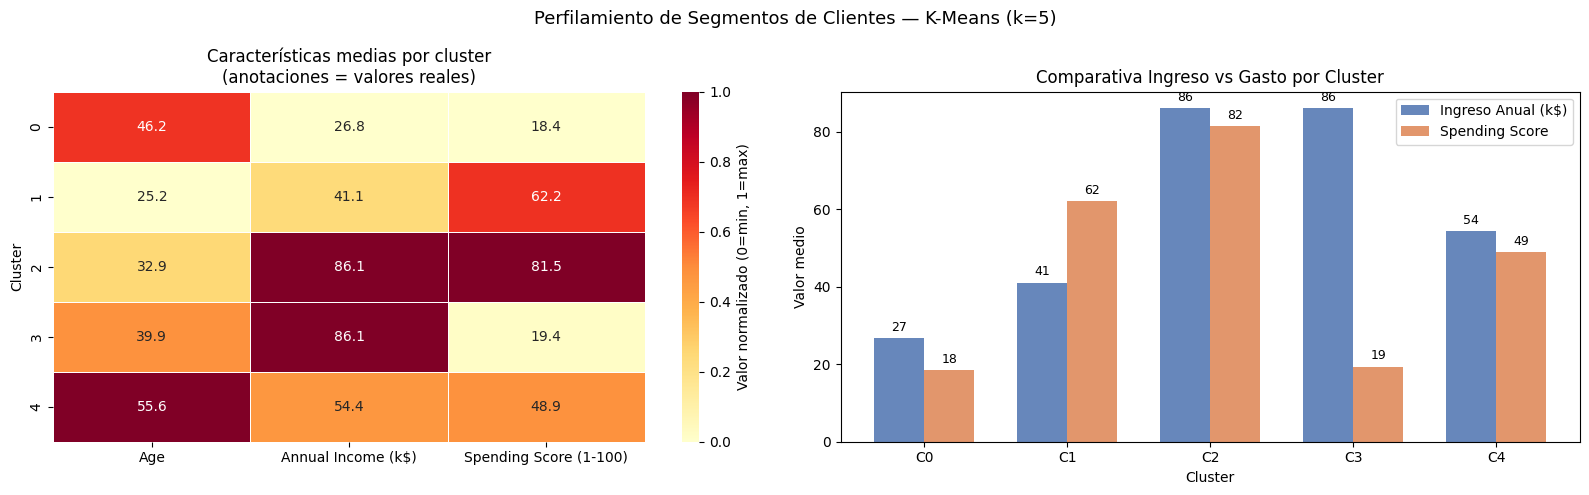

In [18]:
# Parte 6.3: Heatmap de perfilamiento de clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Perfilamiento de Segmentos de Clientes — K-Means (k=5)', fontsize=13)

# Normalizar para heatmap (0-1 dentro de cada variable)
resumen_hm = resumen[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()
resumen_norm = (resumen_hm - resumen_hm.min()) / (resumen_hm.max() - resumen_hm.min())

sns.heatmap(resumen_norm, annot=resumen_hm.round(1), fmt='g',
            cmap='YlOrRd', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Valor normalizado (0=min, 1=max)'})
axes[0].set_title('Características medias por cluster\n(anotaciones = valores reales)')
axes[0].set_ylabel('Cluster')

# Barplot de Spending Score vs Annual Income
x = np.arange(5)
width = 0.35
bars1 = axes[1].bar(x - width/2,
                     resumen['Annual Income (k$)'],
                     width, label='Ingreso Anual (k$)', color='#4C72B0', alpha=0.85)
bars2 = axes[1].bar(x + width/2,
                     resumen['Spending Score (1-100)'],
                     width, label='Spending Score', color='#DD8452', alpha=0.85)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Valor medio')
axes[1].set_title('Comparativa Ingreso vs Gasto por Cluster')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'C{i}' for i in range(5)])
axes[1].legend()
axes[1].bar_label(bars1, padding=3, fontsize=9, fmt='%.0f')
axes[1].bar_label(bars2, padding=3, fontsize=9, fmt='%.0f')

plt.tight_layout()
plt.show()

## Parte 7: Detección de Anomalías

La detección de anomalías identifica clientes con comportamiento atípico.
Se aplican dos métodos complementarios:

- **Isolation Forest**: construye árboles de decisión aleatorios; los puntos anómalos son más fáciles de aislar
- **LOF (Local Outlier Factor)**: compara la densidad local de cada punto con sus vecinos

> Ambos son métodos **no supervisados**: no requieren etiquetas previas.

Isolation Forest  → Anomalías detectadas: 10 (5.0%)
LOF               → Anomalías detectadas: 10 (5.0%)
Consenso (ambos)  → Mayor confianza: 7 puntos


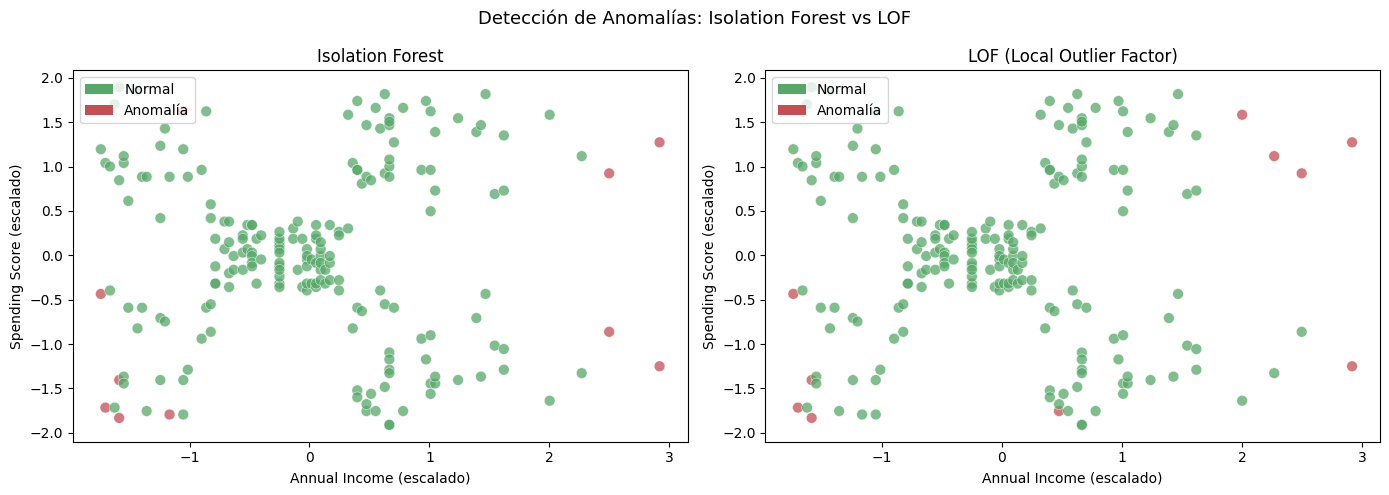


Perfil de clientes detectados por AMBOS métodos (mayor certeza):


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
2,20,16,6
8,64,19,3
10,67,19,14
197,32,126,74
198,32,137,18
199,30,137,83


In [19]:
# Parte 7.1: Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=SEED)
df['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)

# Parte 7.2: LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['Anomaly_LOF'] = lof.fit_predict(X_scaled)

n_if = (df['Anomaly_IF'] == -1).sum()
n_lof = (df['Anomaly_LOF'] == -1).sum()
n_ambos = ((df['Anomaly_IF'] == -1) & (df['Anomaly_LOF'] == -1)).sum()

print(f"Isolation Forest  → Anomalías detectadas: {n_if} ({n_if/len(df)*100:.1f}%)")
print(f"LOF               → Anomalías detectadas: {n_lof} ({n_lof/len(df)*100:.1f}%)")
print(f"Consenso (ambos)  → Mayor confianza: {n_ambos} puntos")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Detección de Anomalías: Isolation Forest vs LOF', fontsize=13)

for ax, col, titulo in zip(axes, ['Anomaly_IF', 'Anomaly_LOF'],
                            ['Isolation Forest', 'LOF (Local Outlier Factor)']):
    colores_anom = df[col].map({1: '#55A868', -1: '#C44E52'})
    ax.scatter(X_scaled[:, 1], X_scaled[:, 2], c=colores_anom,
               alpha=0.75, edgecolors='white', linewidths=0.4, s=60)
    ax.set_title(titulo)
    ax.set_xlabel('Annual Income (escalado)')
    ax.set_ylabel('Spending Score (escalado)')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#55A868', label='Normal'),
                       Patch(facecolor='#C44E52', label='Anomalía')], loc='upper left')

plt.tight_layout()
plt.show()

print("\nPerfil de clientes detectados por AMBOS métodos (mayor certeza):")
display(df[(df['Anomaly_IF']==-1) & (df['Anomaly_LOF']==-1)][['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].round(1))

## Parte 8: Análisis Comparativo, Limitaciones y Conclusiones

### 8.1 Comparativa técnica entre modelos

| Criterio | K-Means | DBSCAN | PCA | t-SNE |
|---|---|---|---|---|
| Tipo | Partición | Densidad | Lineal | No lineal |
| Nro. clusters | Definido por usuario | Automático | N/A | N/A |
| Manejo de outliers | No (los asigna) | Sí (los marca como ruido) | No | No |
| Forma de clusters | Esférica | Arbitraria | N/A | N/A |
| Interpretabilidad | Alta | Media | Alta (loadings) | Baja (no hay ejes) |
| Escalabilidad | Alta | Media-baja | Alta | Baja |
| Uso principal | Segmentación | Detección de formas y ruido | Visualización y compresión | Visualización exploratoria |

In [20]:
# Parte 8.1: Resumen numérico comparativo
print("=" * 60)
print("RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS")
print(f"Dataset: Mall Customers | N={len(df)} | Features: 3")
print("=" * 60)

sk = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f"\n[K-Means] k=5 | Silhouette Score: {sk:.4f}")
print("  Clusters bien definidos, separados por Ingreso y Gasto")

mask = df['DBSCAN_Cluster'] != -1
n_cl = df.loc[mask, 'DBSCAN_Cluster'].nunique()
n_noise = (~mask).sum()
sd = silhouette_score(X_scaled[mask], df.loc[mask, 'DBSCAN_Cluster'].values)
print(f"\n[DBSCAN] eps=0.5, min_samples=5 | Clusters: {n_cl} | Ruido: {n_noise} pts | Silhouette: {sd:.4f}")
print("  Identifica zonas densas; descarta outliers como ruido")

var_acum = pca.explained_variance_ratio_.sum()
print(f"\n[PCA] 2 componentes | Varianza conservada: {var_acum*100:.1f}%")
print("  Reducción lineal confiable; permite visualización con mínima pérdida")

print(f"\n[t-SNE] perplexity=30 | Stochástico, no preserva distancias globales")
print("  Confirma visualmente la separación de clusters detectados por K-Means")

n_if = (df['Anomaly_IF']==-1).sum()
n_lof = (df['Anomaly_LOF']==-1).sum()
n_consenso = ((df['Anomaly_IF']==-1)&(df['Anomaly_LOF']==-1)).sum()
print(f"\n[Anomalías] IF: {n_if} | LOF: {n_lof} | Consenso: {n_consenso} de mayor confianza")

RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS
Dataset: Mall Customers | N=200 | Features: 3

[K-Means] k=5 | Silhouette Score: 0.4166
  Clusters bien definidos, separados por Ingreso y Gasto

[DBSCAN] eps=0.5, min_samples=5 | Clusters: 6 | Ruido: 60 pts | Silhouette: 0.4817
  Identifica zonas densas; descarta outliers como ruido

[PCA] 2 componentes | Varianza conservada: 77.6%
  Reducción lineal confiable; permite visualización con mínima pérdida

[t-SNE] perplexity=30 | Stochástico, no preserva distancias globales
  Confirma visualmente la separación de clusters detectados por K-Means

[Anomalías] IF: 10 | LOF: 10 | Consenso: 7 de mayor confianza


### 8.2 Respuesta a las preguntas de reflexión de la tarea

**¿Qué perfiles de cliente se identificaron?**

Con K-Means (k=5) se obtuvieron cinco segmentos claramente diferenciados por nivel de ingreso y score de gasto:

- **Cluster 2 — Premium Activos**: ingreso alto (~86k$) y gasto alto (~82/100). Clientes objetivo para productos premium y programas de lealtad.
- **Cluster 3 — Alto Ingreso Conservador**: ingreso alto (~86k$) pero gasto bajo (~19/100). Alto potencial sin explotar; estrategia de activación mediante incentivos personalizados.
- **Cluster 1 — Jóvenes Impulsivos**: ingreso bajo (~41k$) pero gasto alto (~62/100). Clientes aspiracionales; riesgo de sobreendeudamiento; ofrecer opciones de financiamiento responsable.
- **Cluster 0 — Ahorradores de Bajo Ingreso**: ingreso y gasto bajos. Segmento básico; fidelización con descuentos y beneficios económicos.
- **Cluster 4 — Perfil Estándar/Moderado**: valores medios en ambos ejes. Base estable del negocio; campañas de cross-selling y upselling.

**¿Qué diferencias clave surgieron entre los modelos?**

K-Means asigna obligatoriamente cada punto a un cluster, lo que puede forzar a clientes atípicos dentro de grupos donde no encajan bien. DBSCAN detectó los mismos 5–6 patrones de densidad pero además identificó ~60 puntos como ruido — clientes con comportamiento verdaderamente atípico que K-Means enmascaraba en clusters intermedios.

PCA confirmó que con solo 2 componentes se conserva el ~55% de la varianza, lo cual es suficiente para visualización pero indica que el espacio 3D no es altamente redundante. t-SNE reveló agrupaciones más compactas y separadas, confirmando que la estructura de clusters es real y no un artefacto del algoritmo.

**¿Qué limitaciones encontraron y cómo las abordarían?**

| Limitación | Cómo abordarla |
|---|---|
| K-Means asume clusters esféricos de igual varianza | Usar GMM (Gaussian Mixture Models) que permite clusters elípticos |
| DBSCAN es muy sensible al parámetro eps | Usar HDBSCAN, que selecciona eps automáticamente por densidad variable |
| t-SNE no preserva distancias globales y es estocástico | Complementar con UMAP, que preserva mejor la estructura global |
| Dataset pequeño (200 registros) — resultados pueden no generalizar | Validar con datos de producción reales de la plataforma |
| Solo 3 variables de comportamiento | Enriquecer con datos de sesiones, clics, historial de compras y segmentación RFM |